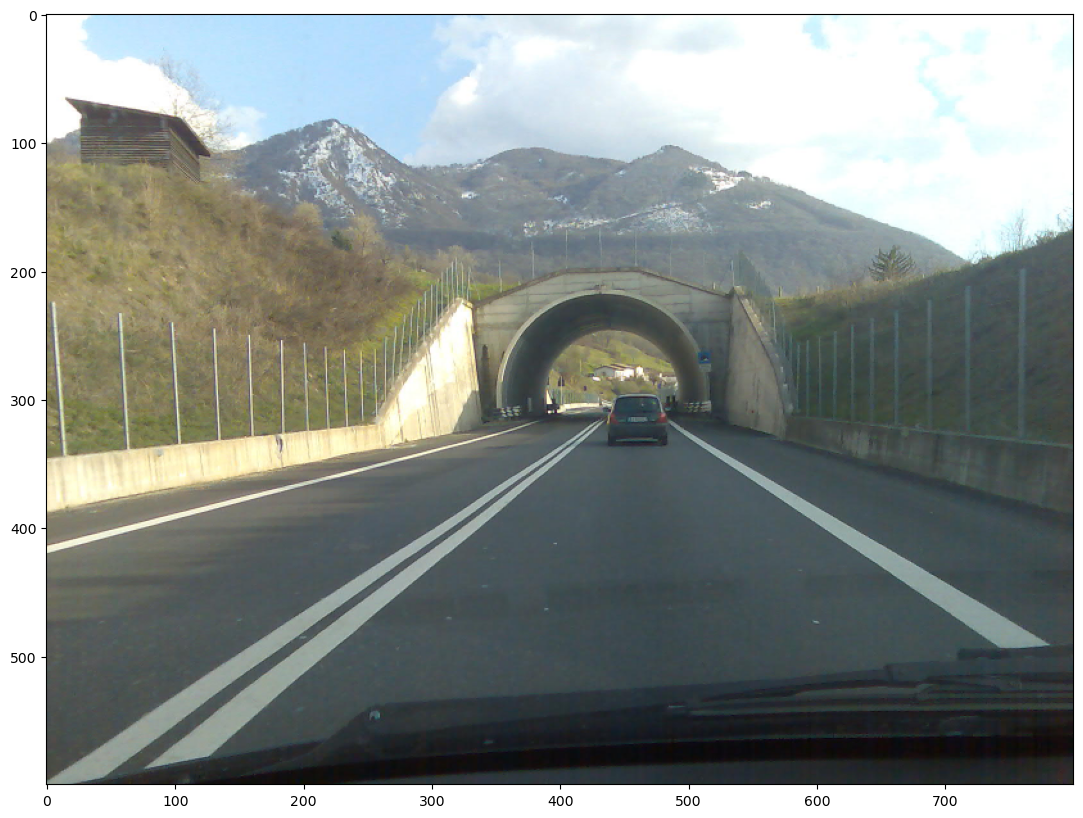

In [24]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

img = cv2.imread('highway.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, None, fx=0.5, fy=0.5)
plt.imshow(img)

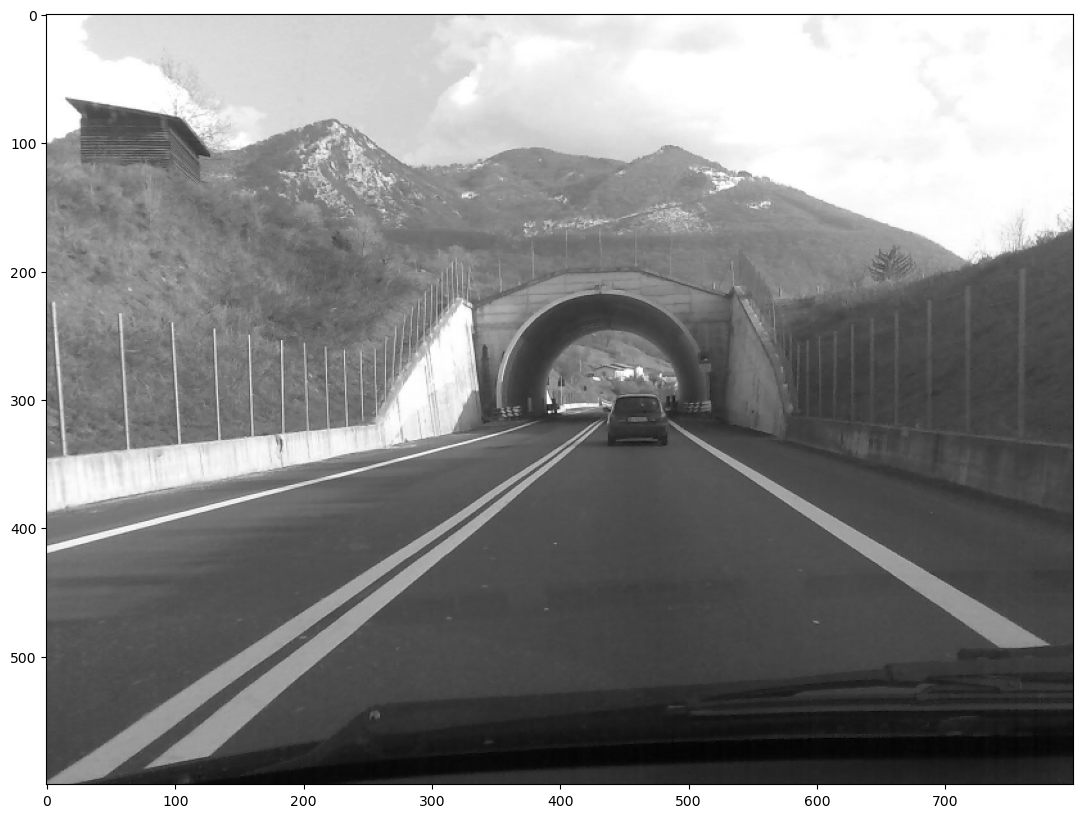

In [25]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')


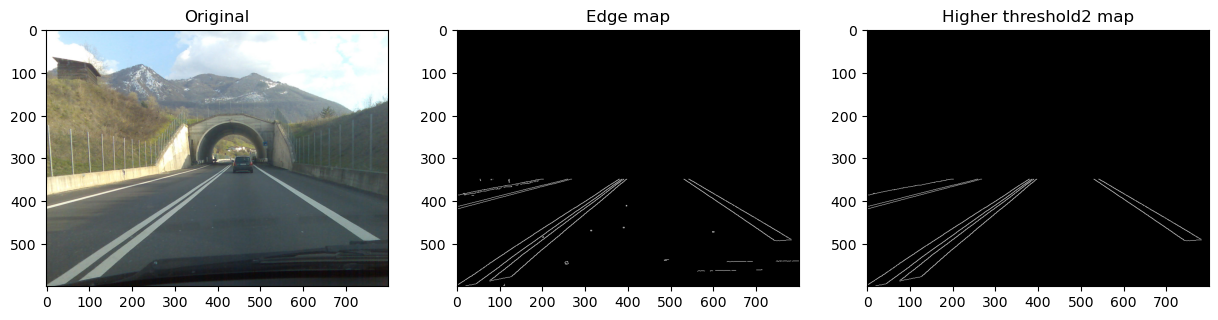

In [63]:
edges = cv2.Canny(gray, threshold1=100, threshold2=150)
edges[0:350] = 0

# With higher second threshold we got even better results without noise and still with all relevant data
# but I will continue to use result with recomended (threshold2=150) as it doesnt affect final results
edgesHigher = cv2.Canny(gray, threshold1=100, threshold2=400)
edgesHigher[0:350] = 0

plt.rcParams['figure.figsize'] = [15, 5]
plt.subplot(131), plt.imshow(img), plt.title('Original')
plt.subplot(132), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(133), plt.imshow(edgesHigher, cmap='gray'), plt.title('Higher threshold2 map')

plt.show()

lines shape  (10, 2)


(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

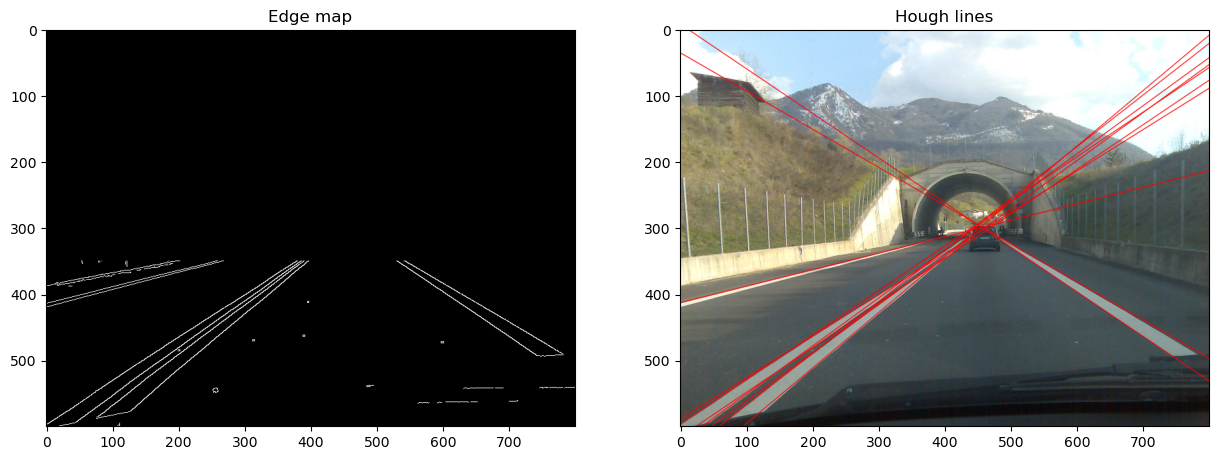

In [69]:
# it will create much more Hough`s lines but anyway future filtering would remove noise
# lines = cv2.HoughLines(edges, rho=30, theta=np.pi/180, threshold=190)

# parameters from hints
lines = cv2.HoughLines(edges, rho=2, theta=np.pi/90, threshold=190)
lines = lines[:, 0, :]

result = np.copy(img)

for rho, theta in lines:
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

print('lines shape ', lines.shape)

plt.rcParams['figure.figsize'] = [15, 10]
plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

before filtering :  (10, 2)
20 degree threshold :  0.3490658503988659
after filtering :  (9, 2)


(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

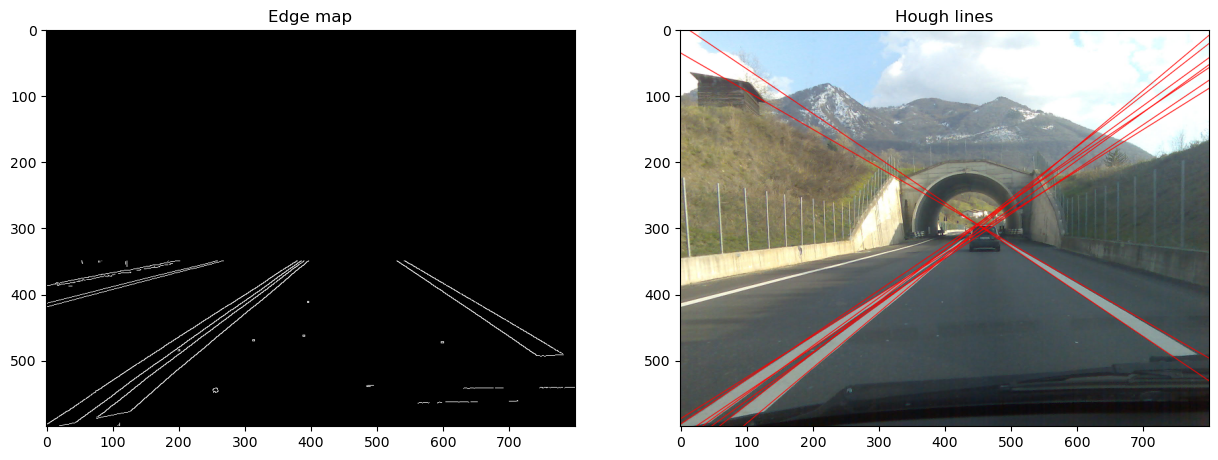

In [72]:
print('before filtering : ', lines.shape)

threshold_angle = (np.pi/180)*20 
print('20 degree threshold : ', threshold_angle)

filtered_lines = []
for line in lines:
    theta = line[1]
    if not (abs(theta - np.pi/2) < threshold_angle):
        filtered_lines.append(line)

print('after filtering : ', np.array(filtered_lines).shape)


# Let's plot the resulting filtered lines
result = np.copy(img)

for rho, theta in filtered_lines:
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)


plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

(<Axes: title={'center': 'Centered Hough lines'}>,
 Text(0.5, 1.0, 'Centered Hough lines'))

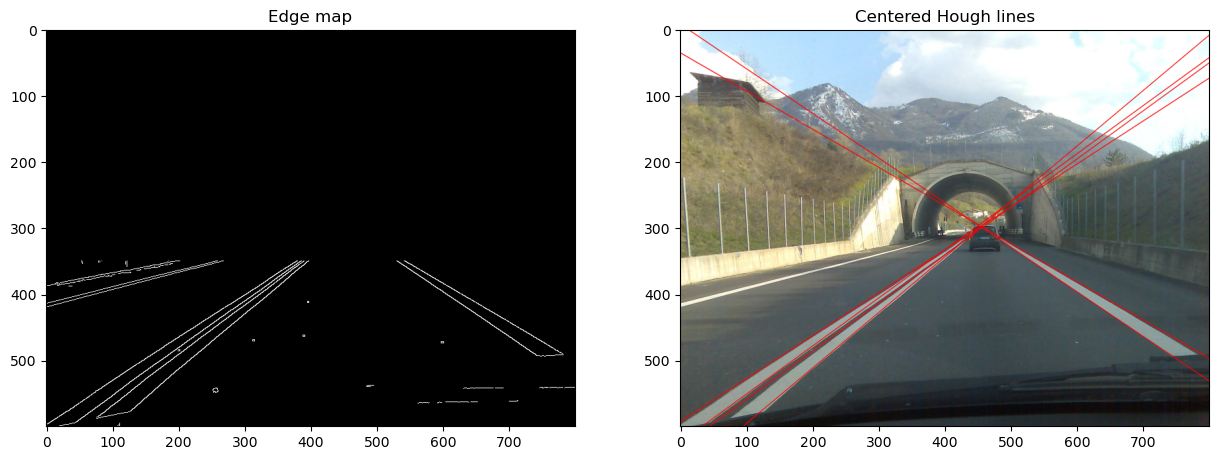

In [74]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6).fit(filtered_lines)
centers = kmeans.cluster_centers_

result = np.copy(img)
    
for rho, theta in centers:
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)


plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Centered Hough lines')



# 1) Do you see anything strange in the final result? - We got lines that display traffic lines that interest for current task. Last step get rid/centered similar lines
# 2) Do you think the Hough transform resolution is important for obtaining a good result? Why? Yes, the transform resolution define that lines could 
# be curved on picture but with hidher parameter we would receive "noise" lines
# 3) Do you think the Hough transform accumulator threshold is important for obtaining a good result? Why? - Yes, accumulator important as it allows 
# to select the srtongest results (in our case lines). Lines that intersects with number of edges >= threshold



# When is the circular Hough transform used?